In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")
df['Score'] = df['Score'].fillna(df['Score'].mean())

x = df['Roll'].values
y = df['Score'].values

n = len(x)

#Normalize
x = (x - x.mean()) / x.std()
print("Normalized Roll Number : ",x[:10])
#Initialize Hyperparams
m = 0.0
c = 0.0
lr = 0.01
iterations = 1000
print("Training")
for i in range(iterations):
    y_pred = m * x + c #y_pred is a list
    #E
    error = y - y_pred #error is a list
    #MSE
    mse = (1/n) * np.sum(error ** 2) #np.sum adds all elements of the list
    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)
    m = m - lr * dm
    c = c - lr * dc
    if i % 100 == 0:
        print(f"Iteration {i} | MSE = {mse:.4f} | m = {m:.4f} | c = {c:.4f}")


print("\nFinal Linear Regression Equation:")
print(f"y = {m:.4f}x + {c:.4f}")


Normalized Roll Number :  [-0.96723089 -0.96722572 -0.96722375 -0.96721902 -0.96721561 -0.96721441
 -0.96721364 -0.96721254 -0.96721243 -0.96721034]
Training
Iteration 0 | MSE = 16.9333 | m = -0.0017 | c = 0.0805
Iteration 100 | MSE = 1.0240 | m = -0.0756 | c = 3.5004
Iteration 200 | MSE = 0.7442 | m = -0.0853 | c = 3.9539
Iteration 300 | MSE = 0.7393 | m = -0.0866 | c = 4.0141
Iteration 400 | MSE = 0.7392 | m = -0.0868 | c = 4.0220
Iteration 500 | MSE = 0.7392 | m = -0.0868 | c = 4.0231
Iteration 600 | MSE = 0.7392 | m = -0.0868 | c = 4.0232
Iteration 700 | MSE = 0.7392 | m = -0.0868 | c = 4.0233
Iteration 800 | MSE = 0.7392 | m = -0.0868 | c = 4.0233
Iteration 900 | MSE = 0.7392 | m = -0.0868 | c = 4.0233

Final Linear Regression Equation:
y = -0.0868x + 4.0233


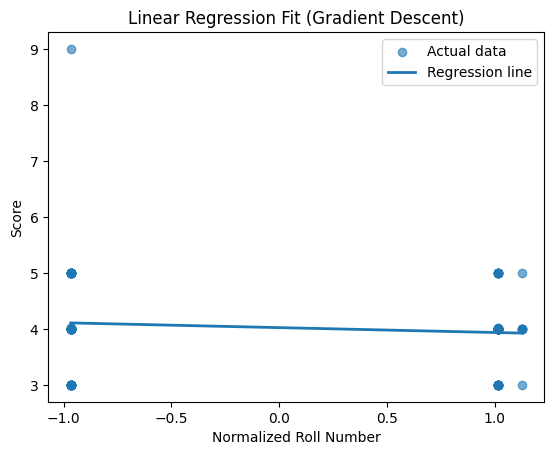

In [21]:
import matplotlib.pyplot as plt

# Generate predictions using the trained model
y_pred = m * x + c

plt.figure()
plt.scatter(x, y, label="Actual data", alpha=0.6)
plt.plot(x, y_pred, label="Regression line", linewidth=2)

plt.xlabel("Normalized Roll Number")
plt.ylabel("Score")
plt.title("Linear Regression Fit (Gradient Descent)")
plt.legend()
plt.show()


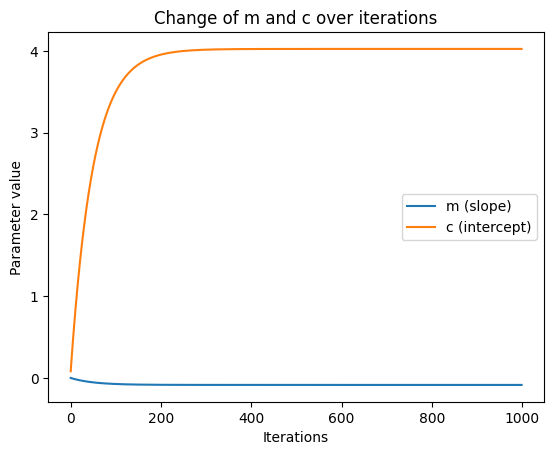

In [20]:
import matplotlib.pyplot as plt

# Lists to store parameter history
m_history = []
c_history = []

# Re-initialize parameters
mi = 0.0
ci = 0.0

# Training with tracking
for i in range(iterations):
    y_pred = mi * x + ci
    error = y - y_pred
    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)
    mi = mi - lr * dm
    ci = ci - lr * dc
    # Store values
    m_history.append(mi)
    c_history.append(ci)

# -----------------------------
# Plot m and c over iterations
# -----------------------------
plt.figure()
plt.plot(m_history, label="m (slope)")
plt.plot(c_history, label="c (intercept)")
plt.xlabel("Iterations")
plt.ylabel("Parameter value")
plt.title("Change of m and c over iterations")
plt.legend()
plt.show()
